In [7]:
import yfinance as yf

# Define the ticker symbol
ticker_symbol = 'AAPL'

# Get data for the ticker
ticker_data = yf.Ticker(ticker_symbol)

# Get historical market data
hist = ticker_data.history(period="1y") # Data for the last 1 year

# Display the first 5 rows of the data
print(f"Displaying historical data for {ticker_symbol}:")
print(hist.head())

Displaying historical data for AAPL:
                                 Open        High         Low       Close  \
Date                                                                        
2025-09-05 00:00:00-04:00  239.116703  240.431852  237.612266  238.807846   
2025-09-08 00:00:00-04:00  238.419289  239.266151  235.470176  237.004517   
2025-09-09 00:00:00-04:00  236.127744  237.901192  232.501141  233.487503   
2025-09-10 00:00:00-04:00  231.335457  231.564607  225.118417  225.955322   
2025-09-11 00:00:00-04:00  226.044995  229.601848  225.815830  229.183395   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-09-05 00:00:00-04:00  54870400        0.0           0.0  
2025-09-08 00:00:00-04:00  48999500        0.0           0.0  
2025-09-09 00:00:00-04:00  66313900        0.0           0.0  
2025-09-10 00:00:00-04:00  83440800        0.0           0.0  
2025-09-11 00:00:00-04:00  50208600        0.

In [8]:
start_date = '2000-01-01'
end_date = '2026-12-31'

# Get historical market data for the specified timeline
# Assuming 'ticker_data' object is still available from the previous cell
hist_timeline = ticker_data.history(start=start_date, end=end_date)

# Display the first 5 rows of the data for the new timeline
print(f"Displaying historical data for {ticker_symbol} from {start_date} to {end_date}:")
print(hist_timeline.head())

Displaying historical data for AAPL from 2000-01-01 to 2026-12-31:
                               Open      High       Low     Close     Volume  \
Date                                                                           
2000-01-03 00:00:00-05:00  0.784193  0.841208  0.760359  0.837002  535796800   
2000-01-04 00:00:00-05:00  0.809429  0.827188  0.756620  0.766435  512377600   
2000-01-05 00:00:00-05:00  0.775781  0.826721  0.770173  0.777650  778321600   
2000-01-06 00:00:00-05:00  0.793540  0.800083  0.710353  0.710353  767972800   
2000-01-07 00:00:00-05:00  0.721570  0.755218  0.714093  0.744002  460734400   

                           Dividends  Stock Splits  
Date                                                
2000-01-03 00:00:00-05:00        0.0           0.0  
2000-01-04 00:00:00-05:00        0.0           0.0  
2000-01-05 00:00:00-05:00        0.0           0.0  
2000-01-06 00:00:00-05:00        0.0           0.0  
2000-01-07 00:00:00-05:00        0.0           0.0  


### Exploratory Data Analysis (EDA) ###

Missing values per column:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Descriptive statistics:
              Open         High          Low        Close        Volume  \
count  6709.000000  6709.000000  6709.000000  6709.000000  6.709000e+03   
mean     54.216869    54.810349    53.666392    54.263775  3.650438e+08   
std      77.858364    78.718993    77.090216    77.945332  3.802539e+08   
min       0.194263     0.197254     0.190225     0.196207  1.791060e+07   
25%       2.229464     2.254887     2.205836     2.232754  1.005660e+08   
50%      16.523896    16.640593    16.343824    16.513004  2.418304e+08   
75%      64.150488    64.985436    63.434420    64.227455  4.897088e+08   
max     339.736982   344.273097   337.059318   339.786926  7.421641e+09   

         Dividends  Stock Splits  
count  6709.000000   6709.000000  
mean      0.001575    

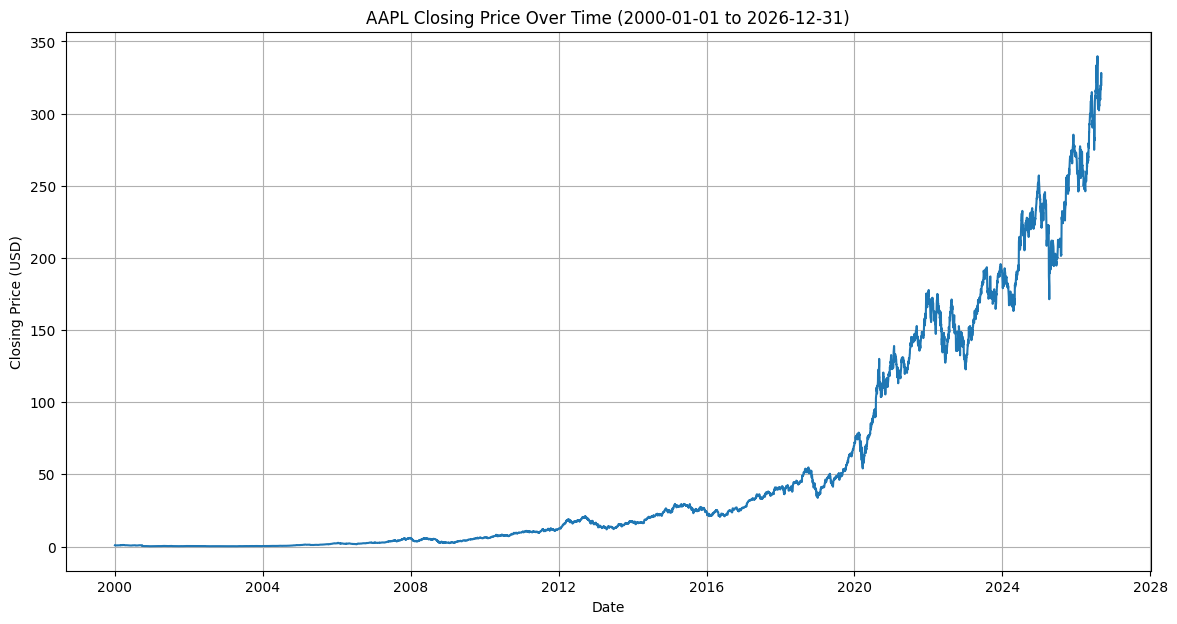

In [9]:
import matplotlib.pyplot as plt

print("### Exploratory Data Analysis (EDA) ###")

# 1. Check for missing values
print("\nMissing values per column:")
print(hist_timeline.isnull().sum())

# 2. Display basic statistics
print("\nDescriptive statistics:")
print(hist_timeline.describe())

# 3. Display data types and non-null counts
print("\nData types and non-null counts:")
hist_timeline.info()

# 4. Visualize Closing Price over Time
plt.figure(figsize=(14, 7))
plt.plot(hist_timeline['Close'])
plt.title(f'{ticker_symbol} Closing Price Over Time ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
plt.show()

# 5. Plot distributions of key columns (optional, can be extensive for all)
# For a quick look at distributions, you can use:
# hist_timeline[['Open', 'High', 'Low', 'Close', 'Volume']].hist(bins=50, figsize=(15,10))
# plt.tight_layout()
# plt.show()


## 2. Data Preprocessing and Feature Engineering

Before building the model, we need to prepare our data. This involves ensuring the date index is correct, creating our target variable, and handling any missing values.

*   **Chronological Splitting:** For time-series data, it's crucial to split the dataset chronologically. This mimics real-world scenarios where we predict future values based on past observations. Random shuffling would introduce future information into the training set, leading to an overly optimistic and unrealistic performance estimate.
*   **Target Column `Target_Close`:** We create this by shifting the `Close` price column by one day (`Close.shift(-1)`). This means that for any given row, `Target_Close` will represent the closing price of the *next* trading day, which is what our model will try to predict.
*   **Handling NaNs:** The last row will have a `NaN` in `Target_Close` because there's no subsequent trading day. We remove this row as it cannot be used for training or testing.

In [10]:
import numpy as np
import pandas as pd

# Ensure the index is a DatetimeIndex and sorted (it should already be)
hist_timeline.index = pd.to_datetime(hist_timeline.index)
hist_timeline = hist_timeline.sort_index()

# Check for any remaining missing values before proceeding
print(f"Missing values before target creation:\n{hist_timeline.isnull().sum()}\n")

# Remove 'Dividends' and 'Stock Splits' if they exist and are not needed for this model
columns_to_drop = ['Dividends', 'Stock Splits']
existing_columns_to_drop = [col for col in columns_to_drop if col in hist_timeline.columns]
hist_timeline = hist_timeline.drop(columns=existing_columns_to_drop)
print(f"Columns dropped: {existing_columns_to_drop}\n")

# Create the target column: next day's Close price
hist_timeline['Target_Close'] = hist_timeline['Close'].shift(-1)

# Remove the last row which will have NaN for Target_Close
hist_timeline = hist_timeline.dropna()

print("Dataset shape after preprocessing:", hist_timeline.shape)
print("First 5 rows of preprocessed data with target:")
display(hist_timeline.head())
print("Last 5 rows of preprocessed data with target:")
display(hist_timeline.tail())

Missing values before target creation:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Columns dropped: ['Dividends', 'Stock Splits']

Dataset shape after preprocessing: (6708, 6)
First 5 rows of preprocessed data with target:


,Open,High,Low,Close,Volume,Target_Close
Date,,,,,,
2000-01-03 00:00:00-05:00,0.784193,0.841208,0.760359,0.837002,535796800,0.766435
2000-01-04 00:00:00-05:00,0.809429,0.827188,0.756620,0.766435,512377600,0.777650
2000-01-05 00:00:00-05:00,0.775781,0.826721,0.770173,0.777650,778321600,0.710353
2000-01-06 00:00:00-05:00,0.793540,0.800083,0.710353,0.710353,767972800,0.744002
2000-01-07 00:00:00-05:00,0.721570,0.755218,0.714093,0.744002,460734400,0.730917


Last 5 rows of preprocessed data with target:


,Open,High,Low,Close,Volume,Target_Close
Date,,,,,,
2026-08-28 00:00:00-04:00,316.850006,322.369995,315.450012,319.700012,38649400,316.850006
2026-08-31 00:00:00-04:00,319.600006,321.239990,312.799988,316.850006,41242700,325.130005
2026-09-01 00:00:00-04:00,316.980011,327.299988,314.730011,325.130005,53167400,324.959991
2026-09-02 00:00:00-04:00,326.869995,328.399994,323.529999,324.959991,33776400,328.209991
2026-09-03 00:00:00-04:00,324.869995,330.809998,324.109985,328.209991,37225800,319.970001


## 3. Feature Selection and Data Splitting

We select the `Open`, `High`, `Low`, `Close`, and `Volume` as our features. The `Target_Close` is our dependent variable. We then split the data into training and testing sets, maintaining chronological order.

*   **Feature Scaling:** Scaling features (like using `StandardScaler` or `MinMaxScaler`) is crucial for neural networks. It helps in faster convergence during training and prevents features with larger numerical ranges from dominating the learning process. It normalizes the data to a standard range or distribution. We fit the scaler *only* on the training data to prevent **data leakage**, which would occur if information from the test set influenced the scaling of the training set.

In [11]:
from sklearn.preprocessing import MinMaxScaler

# Define features (X) and target (y)
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = hist_timeline[features]
y = hist_timeline['Target_Close']

# Split data chronologically (80% train, 20% test)
train_size = int(len(hist_timeline) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Original dataset shape:", hist_timeline.shape)
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# The target 'y' is a single value and typically not scaled if it's the raw price
# If we were predicting a percentage change or a scaled version of the price,
# we would scale y as well. For raw price prediction, keeping it unscaled is common.

print("\nFeatures scaled successfully.")

Original dataset shape: (6708, 6)
Training features shape: (5366, 5)
Testing features shape: (1342, 5)
Training target shape: (5366,)
Testing target shape: (1342,)

Features scaled successfully.


## 4. Build and Train the Feedforward Neural Network (FNN)

A Feedforward Neural Network (FNN) is chosen for this task due to its simplicity and effectiveness for structured data like time series when the immediate past values are used as direct features to predict the next value. Unlike Recurrent Neural Networks (RNNs) or LSTMs, FNNs don't inherently handle sequences over long periods, but by providing lagged features (which is effectively what 'Open', 'High', 'Low', 'Close', 'Volume' from the current day are in relation to the 'next day's close'), they can capture relevant patterns for short-term predictions. They are generally faster to train and less complex to implement for this specific setup where the input is a fixed-size vector representing daily stock metrics.

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build the FNN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression (single value prediction)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

print("Model summary:")
model.summary()

Model summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

We will train the FNN using the scaled training data. Early stopping is incorporated to prevent overfitting by monitoring the validation loss and stopping training if it doesn't improve for a certain number of epochs (patience). This also helps in restoring the model weights from the epoch with the best validation performance.

In [13]:
# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32,
                    validation_split=0.1, callbacks=[early_stopping], verbose=1)

print("\nModel training complete.")

Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 139.9919 - mae: 7.7092 - val_loss: 38.7810 - val_mae: 4.9113
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.9883 - mae: 1.3047 - val_loss: 38.3846 - val_mae: 5.0273
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.7358 - mae: 1.1956 - val_loss: 31.5632 - val_mae: 4.6188
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.2800 - mae: 1.1024 - val_loss: 18.2800 - val_mae: 3.3481
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2271 - mae: 1.0692 - val_loss: 14.5103 - val_mae: 2.9081
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1819 - mae: 1.0376 - val_loss: 23.6649 - val_mae: 4.0068
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3205 - mae: 1.0309 - val_loss: 5.5356 - val_mae: 1.6199
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2165 - mae: 1.0406 - val_loss: 14.9786 - val_mae: 3.1129
Epoch 9/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

## 6. Make Predictions and Evaluate the Model

After training, we use the model to make predictions on the unseen test data. We then evaluate its performance using several regression metrics to understand how well it predicts the next day's closing price.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the scaled test data
y_pred_scaled = model.predict(X_test_scaled)

# Since the target 'y' was not scaled, the predictions are already in the original scale.
y_pred = y_pred_scaled.flatten()

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test, y_pred)

print("\n--- Model Evaluation on Test Set ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R² Score): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Model Evaluation on Test Set ---
Mean Absolute Error (MAE): 2.9731
Mean Squared Error (MSE): 15.9541
Root Mean Squared Error (RMSE): 3.9943
R-squared (R² Score): 0.9937
Mean Absolute Percentage Error (MAPE): 1.5227%


## 7. Visualize Results

Visualizing the actual vs. predicted closing prices helps us understand the model's performance graphically, showing how closely the predictions follow the true values. The training vs. validation loss plot helps us diagnose overfitting or underfitting.

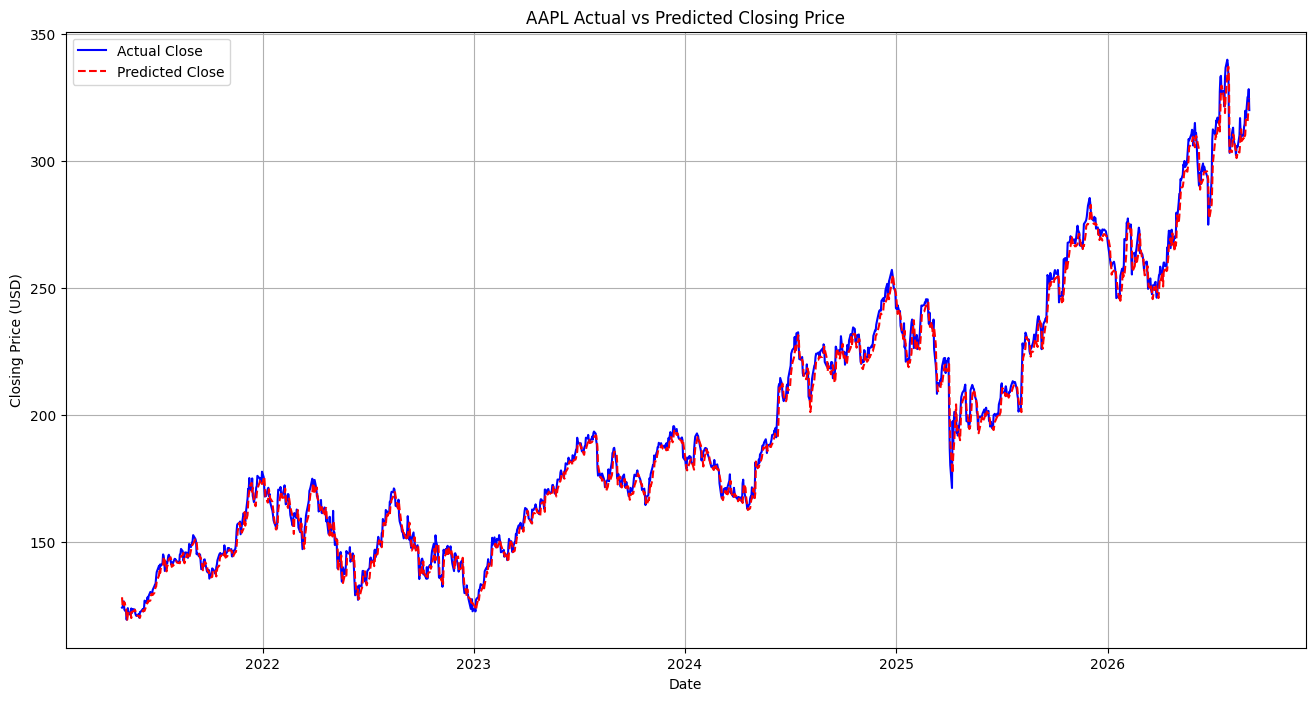

In [15]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted Closing Price
plt.figure(figsize=(16, 8))
plt.plot(y_test.index, y_test, label='Actual Close', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Close', color='red', linestyle='--')
plt.title('AAPL Actual vs Predicted Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

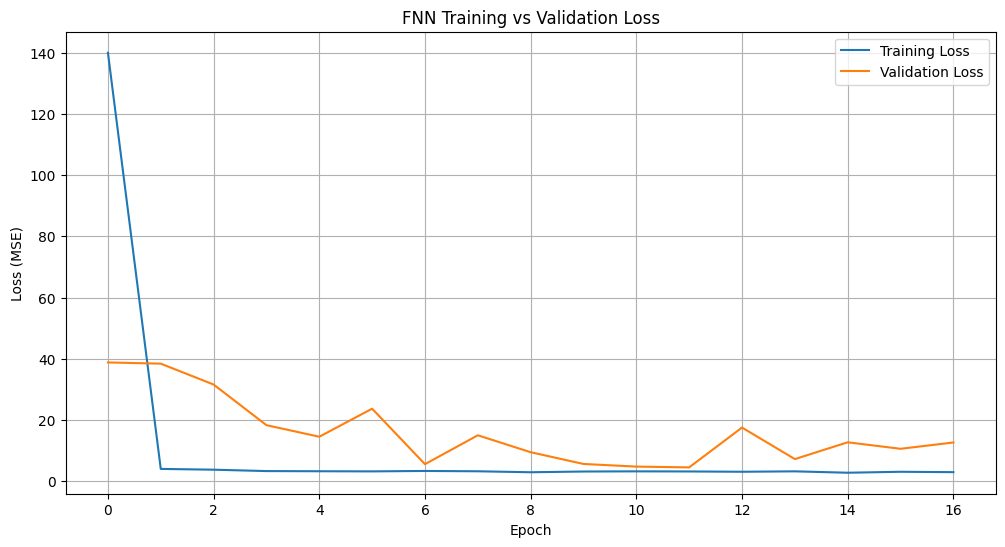

In [16]:
# Plot Training vs Validation Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('FNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Display DataFrame with Date, Actual_Close, Predicted_Close
results_df = pd.DataFrame({
    'Date': y_test.index,
    'Actual_Close': y_test,
    'Predicted_Close': y_pred
})
results_df = results_df.set_index('Date')

print("\nActual vs Predicted Closing Prices on Test Set:")
display(results_df.head())
display(results_df.tail())


Actual vs Predicted Closing Prices on Test Set:


,Actual_Close,Predicted_Close
Date,,
2021-05-03 00:00:00-04:00,124.303497,128.390137
2021-05-04 00:00:00-04:00,124.546577,125.120422
2021-05-05 00:00:00-04:00,126.141075,124.815529
2021-05-06 00:00:00-04:00,126.813072,124.555023
2021-05-07 00:00:00-04:00,123.540733,126.504623


,Actual_Close,Predicted_Close
Date,,
2026-08-28 00:00:00-04:00,316.850006,316.196106
2026-08-31 00:00:00-04:00,325.130005,315.156464
2026-09-01 00:00:00-04:00,324.959991,318.611206
2026-09-02 00:00:00-04:00,328.209991,323.441925
2026-09-03 00:00:00-04:00,319.970001,324.530365


## 8. Interpretation of Model Performance

The `AAPL Actual vs Predicted Closing Price` plot visually demonstrates how well our FNN tracks the actual closing prices. Ideally, the red dashed line (predicted) should closely follow the blue line (actual). Any significant deviations or lag would indicate areas where the model struggles.

From the plot, we can observe:
*   **General Trend:** The model seems to capture the general trend of the stock price, which is a good sign for predicting time series.
*   **Volatility:** In periods of high volatility or sudden price changes, there might be some lag or under/over-prediction, which is common for FNNs given their limitations in capturing complex temporal dependencies compared to sequence models like LSTMs.
*   **Accuracy:** The close proximity of the predicted line to the actual line indicates a reasonable level of accuracy for next-day price prediction, although small errors are always present in financial forecasting.

The evaluation metrics (MAE, MSE, RMSE, R²) provide quantitative measures of this visual assessment. A low MAE/RMSE and an R² score closer to 1 suggest better model performance. The MAPE gives an intuitive understanding of the prediction error as a percentage of the actual value.